### Heart Disease Classifier for all Basic Machine Learning - HuyIGW04

In [356]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, \
                        AdaBoostClassifier, GradientBoostingClassifier, \
                        StackingClassifier
from xgboost import XGBClassifier

In [330]:
df = pd.read_csv('cleveland.csv')
df.columns = ['Age', 'sex', 'Chest Pain', 'Blood Pressure', \
            'Serum', 'Blood Sugar', 'Resting ECG', 'heart rate', \
            'angina', 'depression', 'Peak', 'major vessel', 'thalassemia',\
                'Heart Disease']
df.head(8)

,Age,sex,Chest Pain,Blood Pressure,Serum,Blood Sugar,Resting ECG,heart rate,angina,depression,Peak,major vessel,thalassemia,Heart Disease
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
6,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2


In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             302 non-null    int64  
 1   sex             302 non-null    int64  
 2   Chest Pain      302 non-null    int64  
 3   Blood Pressure  302 non-null    int64  
 4   Serum           302 non-null    int64  
 5   Blood Sugar     302 non-null    int64  
 6   Resting ECG     302 non-null    int64  
 7   heart rate      302 non-null    int64  
 8   angina          302 non-null    int64  
 9   depression      302 non-null    float64
 10  Peak            302 non-null    int64  
 11  major vessel    298 non-null    float64
 12  thalassemia     300 non-null    float64
 13  Heart Disease   302 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.2 KB


In [332]:
df['Heart Disease'].unique()


array([2, 1, 0, 3, 4], dtype=int64)

In [333]:
label = {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}
df['Heart Disease'] = df['Heart Disease'].map(label)
df.head(8)

,Age,sex,Chest Pain,Blood Pressure,Serum,Blood Sugar,Resting ECG,heart rate,angina,depression,Peak,major vessel,thalassemia,Heart Disease
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
6,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1


In [334]:
df['major vessel'] = df['major vessel'].fillna(df['major vessel'].mean())
df['thalassemia'] = df['thalassemia'].fillna(df['thalassemia'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             302 non-null    int64  
 1   sex             302 non-null    int64  
 2   Chest Pain      302 non-null    int64  
 3   Blood Pressure  302 non-null    int64  
 4   Serum           302 non-null    int64  
 5   Blood Sugar     302 non-null    int64  
 6   Resting ECG     302 non-null    int64  
 7   heart rate      302 non-null    int64  
 8   angina          302 non-null    int64  
 9   depression      302 non-null    float64
 10  Peak            302 non-null    int64  
 11  major vessel    302 non-null    float64
 12  thalassemia     302 non-null    float64
 13  Heart Disease   302 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.2 KB


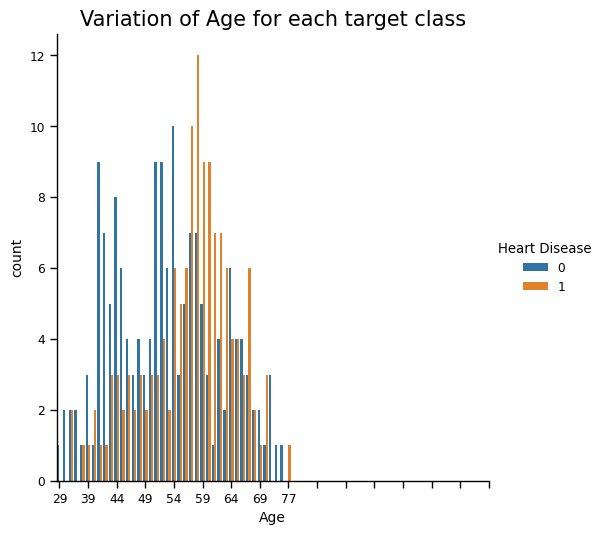

In [335]:
# distribution of target vs age
sns.set_context("paper", font_scale = 1, rc = {"font.size": 3,"axes.titlesize": 15,"axes.labelsize": 10})
ax = sns.catplot(kind = 'count', data = df, x = 'Age', hue = 'Heart Disease', order = df['Age'].sort_values().unique())
# ax.set(xticklabels=[])
ax.ax.set_xticks(np.arange(0, 80, 5))
plt.title('Variation of Age for each target class')
plt.show()

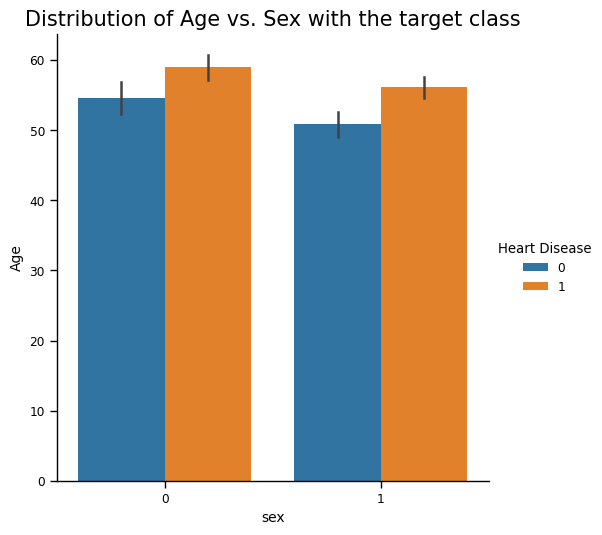

In [336]:
sns.catplot(kind = 'bar', data = df, y = 'Age', x = 'sex', hue = 'Heart Disease')
plt.title('Distribution of Age vs. Sex with the target class')
plt.show()

In [337]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1].astype(int)
print(X.shape, y.shape)

(302, 13) (302,)


In [338]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(f'train set: {X_train.shape}, {y_train.shape}')
print(f'test set: {X_test.shape}, {y_test.shape}')

train set: (241, 13), (241,)
test set: (61, 13), (61,)


In [339]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### KNN Classifier

In [340]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [341]:
y_hat = knn_model.predict(X_test)
cm_y_test = confusion_matrix(y_test, y_hat)
y_pred_train = knn_model.predict(X_train)
cm_y_train = confusion_matrix(y_train, y_pred_train)

accuracy_for_train = np.round((cm_y_train[0][0] + cm_y_train[1][1])/len(y_train), 2)
accuracy_for_test = np.round((cm_y_test[0][0] + cm_y_test[1][1])/len(y_test), 2)

print('accuracy for train set for KNNClassifier = {}'.format(accuracy_for_train))
print('accuracy for test set for KNNClassifier = {}'.format(accuracy_for_test))

accuracy for train set for KNNClassifier = 0.88
accuracy for test set for KNNClassifier = 0.84


### SVM Classifier

In [342]:
svm_model = SVC(kernel='rbf', random_state=2)
svm_model.fit(X_train,  y_train)

SVC(random_state=2)

In [343]:
y_train_pred = svm_model.predict(X_train) 
y_test_pred = svm_model.predict(X_test)

cm_y_train = confusion_matrix(y_train, y_train_pred)
cm_y_test = confusion_matrix(y_test, y_test_pred)

accuracy_train_set = np.round((cm_y_train[0][0] + cm_y_train[1][1])/len(y_train), 2)
accuracy_test_set = np.round((cm_y_test[0][0] + cm_y_test[1][1])/len(y_test), 2)

print("accuracy for train set for SVM Classifier: {}".format(accuracy_train_set))
print("accuracy for train set for SVM Classifier: {}".format(accuracy_test_set))

accuracy for train set for SVM Classifier: 0.91
accuracy for train set for SVM Classifier: 0.84


### Naive Bayes Classifier

In [344]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [345]:
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

train_accuracy = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
test_accuracy = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print('Accuracy for train set using Naive Bayes Classifier: {}'.format(train_accuracy))
print('Accuracy for test set using Naive Bayes Classifier: {}'.format(test_accuracy))

Accuracy for train set using Naive Bayes Classifier: 0.87
Accuracy for test set using Naive Bayes Classifier: 0.79


### Deicision Tree Classifier

In [346]:
dc_model = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=2)
dc_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [347]:
train_prediction = dc_model.predict(X_train)
test_prediction = dc_model.predict(X_test)

cm_train = confusion_matrix(y_train, train_prediction)
cm_test = confusion_matrix(y_test, test_prediction)

accuracy_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print("accuracy for train set using DecisionTree Classifier: {}".format(accuracy_train))
print("accuracy for test set using DecisionTree Classifier: {}".format(accuracy_test))

accuracy for train set using DecisionTree Classifier: 1.0
accuracy for test set using DecisionTree Classifier: 0.77


### Random Forest Classifier

In [348]:
rf_model = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=10,\
                                min_samples_split=2, random_state=2)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=10, random_state=2)

In [349]:
train_prediction = rf_model.predict(X_train)
test_prediction = rf_model.predict(X_test)

cm_train = confusion_matrix(y_train, train_prediction)
cm_test = confusion_matrix(y_test, test_prediction)

accuracy_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print("accuracy for train set using DecisionTree Classifier: {}".format(accuracy_train))
print("accuracy for test set using DecisionTree Classifier: {}".format(accuracy_test))

accuracy for train set using DecisionTree Classifier: 0.99
accuracy for test set using DecisionTree Classifier: 0.8


### AdaBoost Classifier

In [350]:
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0)
ada_model.fit(X_train, y_train)

AdaBoostClassifier()

In [351]:
y_train_pred = ada_model.predict(X_train)
y_test_pred = ada_model.predict(X_test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

accuracy_train_set = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test_set = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print('accuracy for train set using AdaBoost Classifier: {}'.format(accuracy_train_set))
print('accuracy for test set using AdaBoost Classifier: {}'.format(accuracy_test_set))

accuracy for train set using AdaBoost Classifier: 0.91
accuracy for test set using AdaBoost Classifier: 0.79


### Gradient Boost Classifier

In [352]:
gd_model = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    min_samples_split=2,
    max_depth=3,
    random_state=2
)

gd_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=2)

In [353]:
train_prediction = gd_model.predict(X_train)
test_prediction = gd_model.predict(X_test)

cm_train = confusion_matrix(y_true=y_train, y_pred=train_prediction)
cm_test = confusion_matrix(y_true=y_test, y_pred=test_prediction)

accuracy_train_set = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test_set = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print('accuracy for train set using Gradient Boost Classification: {}'.format(accuracy_train_set))
print('accuracy for test set using Gradient Boost Classification: {}'.format(accuracy_test_set))

accuracy for train set using Gradient Boost Classification: 1.0
accuracy for test set using Gradient Boost Classification: 0.77


### XGBoost Classifier

In [354]:
xg_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    random_state=42
)
xg_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [355]:
train_prediction = xg_model.predict(X_train)
test_prediction = xg_model.predict(X_test)

cm_train = confusion_matrix(y_true=y_train, y_pred=train_prediction)
cm_test = confusion_matrix(y_true=y_test, y_pred=test_prediction)

accuracy_train_set = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test_set = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print('accuracy for train set using XGBoost Classification: {}'.format(accuracy_train_set))
print('accuracy for test set using XGBoost Classification: {}'.format(accuracy_test_set))

accuracy for train set using XGBoost Classification: 1.0
accuracy for test set using XGBoost Classification: 0.79


### Stacking

In [377]:
dtc = DecisionTreeClassifier(random_state=3)
svc = SVC(kernel='rbf', random_state=3)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=3)
adb = AdaBoostClassifier(random_state=3)
grb = GradientBoostingClassifier(random_state=3)
xgb = XGBClassifier()

lf= [ ('dtc', dtc), ('svc', svc), ('knn', knn), ('rf', rf), ('adb', adb), ('grb', grb), ('xgb', xgb)]
stacking_model = StackingClassifier(estimators=lf)
stacking_model.fit(X_train, y_train)

StackingClassifier(estimators=[('dtc', DecisionTreeClassifier(random_state=3)),
                               ('svc', SVC(random_state=3)),
                               ('knn', KNeighborsClassifier()),
                               ('rf', RandomForestClassifier(random_state=3)),
                               ('adb', AdaBoostClassifier(random_state=3)),
                               ('grb',
                                GradientBoostingClassifier(random_state=3)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsampl...
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))])

In [376]:
train_prediction = stacking_model.predict(X_train)
test_prediction = stacking_model.predict(X_test)

cm_train = confusion_matrix(y_true=y_train, y_pred=train_prediction)
cm_test = confusion_matrix(y_true=y_test, y_pred=test_prediction)

accuracy_train_set = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train), 2)
accuracy_test_set = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test), 2)

print('accuracy for train set using Stacking Classification: {}'.format(accuracy_train_set))
print('accuracy for test set using Stacking Classification: {}'.format(accuracy_test_set))

accuracy for train set using Stacking Classification: 0.96
accuracy for test set using Stacking Classification: 0.84
